## Implement ReAct with LangGraph-What is ReAct?

- ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
    - Think → Retrieve → Observe → Reflect → Final Answer

In [1]:
from __future__ import annotations

In [2]:
import os
import uuid
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

c:\Users\mani2\Documents\RAG-Mastery\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
# 1. Create Retriever Tool

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [4]:
retriever.invoke("what are autonomous agents")

[Document(id='3c5a2ad0-6e3a-4797-84bc-5710cab71c28', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [5]:
def retriever_tool_func(query: str) -> str:
    print("Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [6]:
retriever_tool_func("what are autonomous agents")

Using RAGRetriever tool


'Or\n@article{weng2023agent,\n  title   = "LLM-powered Autonomous Agents",\n  author  = "Weng, Lilian",\n  journal = "lilianweng.github.io",\n  year    = "2023",\n  month   = "Jun",\n  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"\n}\nReferences#\n[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022\n[2] Yao et al. “Tree of Thoughts: Dliberate Problem Solving with Large Language Models.” arXiv preprint arXiv:2305.10601 (2023).\nBoiko et al. (2023) also looked into LLM-empowered agents for scientific discovery, to handle autonomous design, planning, and performance of complex scientific experiments. This agent can use tools to browse the Internet, read documentation, execute code, call robotics experimentation APIs and leverage other LLMs.\nFor example, when requested to "develop a novel anticancer drug", the model came up with the following reasoning steps:\nCitation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered

In [7]:
retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [8]:
# Wikipedia tool
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\mani2\\Documents\\RAG-Mastery\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [9]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-4o")

C:\Users\mani2\AppData\Local\Temp\ipykernel_45448\1443030924.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(llm,tools)


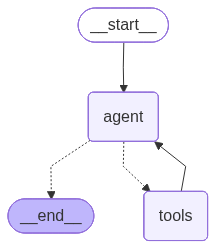

In [10]:
# 2. Define the Agent Node
tools = [retriever_tool, wiki_tool]

# create the native Langgraph react agent
react_node=create_react_agent(llm,tools)
react_node

In [11]:
# 3. LangGraph Agent State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

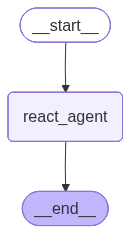

In [12]:
# 4. Build LangGraph Graph
builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [13]:
# 5. Run the ReAct Agent
if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n Final Answer:\n", result["messages"][-1].content)

Using RAGRetriever tool

 Final Answer:
 ### Agent Loop

The concept of an "agent loop" is related to building agents, particularly learning agents using reinforcement learning (RL). A typical agent loop may involve the agent making observations of its environment, taking actions based on these observations, and learning from the consequences of these actions to improve future performance. This loop involves cycles where the agent's experience is concatenated and fed back into its learning model, thereby aiming to improve its decision-making over time. Such improvements are geared towards better overall task performance and autonomously handling complex scientific experiments by utilizing large language models (LLMs).

### Autonomous Agents on Wikipedia

Wikipedia defines autonomous agents as follows:

- **Autonomous Agent**:
  - An autonomous agent is an artificial intelligence (AI) system that can perform complex tasks independently.

- **Intelligent Agent**:
  - In artificial intell

## Tool creation for RAG agents with langgraph 

- To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

- LangGraph uses the Tool abstraction from LangChain and fully supports tools for:
    - RAG retrieval
    - Search
    - Wikipedia
    - SQL
    - Web APIs
    - Calculators, etc.

### Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [14]:
import os
import uuid
from typing import Annotated, Sequence, TypedDict
from langchain_community.tools import Tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_community.document_loaders import TextLoader

In [15]:
llm

ChatOpenAI(profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001C74B1DD850>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C74B1DE610>, root_client=<openai.OpenAI object at 0x000001C74B1DD350>, root_async_client=<openai.AsyncOpenAI object at 0x000001C74B1DE310>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('*****

In [ ]:
# Generic function to create a retireval tool
def make_retriever_tool_from_text(file,name,desc):
    docs=TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(
        chunk_size=500, 
        chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        print(f"Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name,description=desc,func=tool_func)

# Wikipedia Tool
wiki = WikipediaAPIWrapper()

def wiki_func(query: str) -> str:
    print("Using Wikipedia tool")
    return wiki.run(query)

wiki_tool = Tool(
    name="Wikipedia",
    description="Use this tool to fetch general knowledge from Wikipedia.",
    func=wiki_func
)

# ArXiv Tool
def arxiv_search(query: str) -> str:
    print("Searching ArXiv...")
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."

arxiv_tool = Tool(
    name="ArxivSearch",
    description="Use this tool to fetch recent academic papers on technical topics.",
    func=arxiv_search
)


In [22]:
internal_tool_1 = make_retriever_tool_from_text(
    "internal_docs.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)
internal_tool_1

Tool(name='InternalTechDocs', description='Search internal tech documents for proprietary architecture and methods.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000001C77F56B560>)

In [23]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2

Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results and agent designs.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000001C7752D9760>)

C:\Users\mani2\AppData\Local\Temp\ipykernel_45448\1687477868.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(llm,tools)


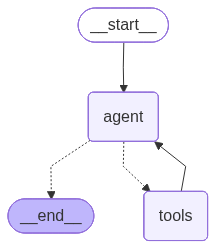

In [25]:
tools=[wiki_tool,arxiv_tool,internal_tool_1,internal_tool_2]

react_node=create_react_agent(llm,tools)
react_node

In [26]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

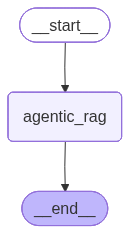

In [27]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph


In [28]:
query = "What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n Final Answer:\n", result["messages"][-1].content)

Using tool: InternalResearchNotes
Searching ArXiv...

 Final Answer:
 From our internal research notes, several transformer variants have been evaluated:

1. **EfficientFormer**: Achieves high accuracy on datasets like TinyImageNet, performing well in quantized int8 mode with minimal accuracy drop, making it suitable for deployment on low-resource devices like Raspberry Pi 4.

2. **Longformer**: Used for processing long sequences such as customer support logs, with room for improvement in reducing query latency through chunk-based hybrid attention.

3. **Reformer**: Encountered training challenges like bucket collisions and loss spikes, which were addressed using techniques like gradient clipping and memory-efficient attention modules.

4. **TinyBERT**: Applied in support ticket priority tagging achieving an 87% F1 score, showing potential for domain transfer with additional components like a 2-layer FFN adapter.

5. Recent advancements like **FlashAttention2** and **Chain-of-Thought p